# **Definición de Objetivos de ML (Alineados con ODS 2 y 3)**

El proyecto ALDIMI Predict busca construir un ecosistema de gestión inteligente mediante Inteligencia Artificial y Machine Learning. Los objetivos de Machine Learning del proyecto son:

1. **Predicción de Demanda y Logística (Alineado con ODS 2 - Hambre Cero):** Desarrollar un modelo de predicción (regresión o series temporales) para anticipar la demanda de inventario (medicamentos y alimentos) a 7 y 14 días. Esto optimiza el abastecimiento y reduce el riesgo de desabastecimiento, asegurando nutrición y acceso a insumos básicos para las familias.

2. **Clasificación de Riesgo de Salud (Alineado con ODS 3 - Salud y Bienestar):** Entrenar un modelo de clasificación que permita identificar de forma temprana el 'Nivel de Prioridad de Atención' (Bajo, Medio, Alto) de los pacientes según sus variables clínicas y sociales. Esto facilita una respuesta médica oportuna y eficiente para evitar complicaciones clínicas.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df_cancer = pd.read_csv('cancer-risk-factors.csv')
df_inventory = pd.read_csv('inventory_data.csv')

# **1. ESTADÍSTICAS INICIALES: RIESGO DE CÁNCER**


### 1.1 Vista Previa de los Datos
Inspección de las primeras filas del dataset para comprender su estructura y las variables disponibles.


In [ ]:
df_cancer.head()


### 1.2 Información del Dataset y Tipos de Datos
Revisión de los tipos de datos y la memoria utilizada, útil para identificar si hay variables categóricas mal formateadas.


In [ ]:
df_cancer.info()


### 1.3 Estadísticas Descriptivas
Resumen estadístico de las variables numéricas (media, desviación estándar, cuartiles).


In [ ]:
df_cancer.describe()


### 1.4 Valores Nulos por Columna
Verificación de la existencia de datos faltantes en el dataset de salud.


In [ ]:
df_cancer.isna().sum()


### 1.5 Porcentaje de Valores en Cero
Análisis de la proporción de ceros en cada columna, lo que puede indicar categorías ausentes, valores nulos implícitos o características esparcidas.


In [ ]:
(df_cancer == 0).mean() * 100


# **2. ESTADÍSTICAS INICIALES: INVENTARIO LOGÍSTICO**


### 2.1 Vista Previa de los Datos
Inspección de las primeras filas del dataset logístico.


In [ ]:
df_inventory.head()


### 2.2 Información del Dataset y Tipos de Datos
Revisión general de la estructura y tipos de variables del inventario.


In [ ]:
df_inventory.info()


### 2.3 Estadísticas Descriptivas
Resumen estadístico de las cantidades de inventario, costos y uso.


In [ ]:
df_inventory.describe()


### 2.4 Valores Nulos por Columna
Verificación de datos faltantes en el control de inventario.


In [ ]:
df_inventory.isna().sum()


### 2.5 Porcentaje de Valores en Cero
Identificación de posibles faltas de stock (ceros) o datos de uso incompletos.


In [ ]:
(df_inventory == 0).mean() * 100


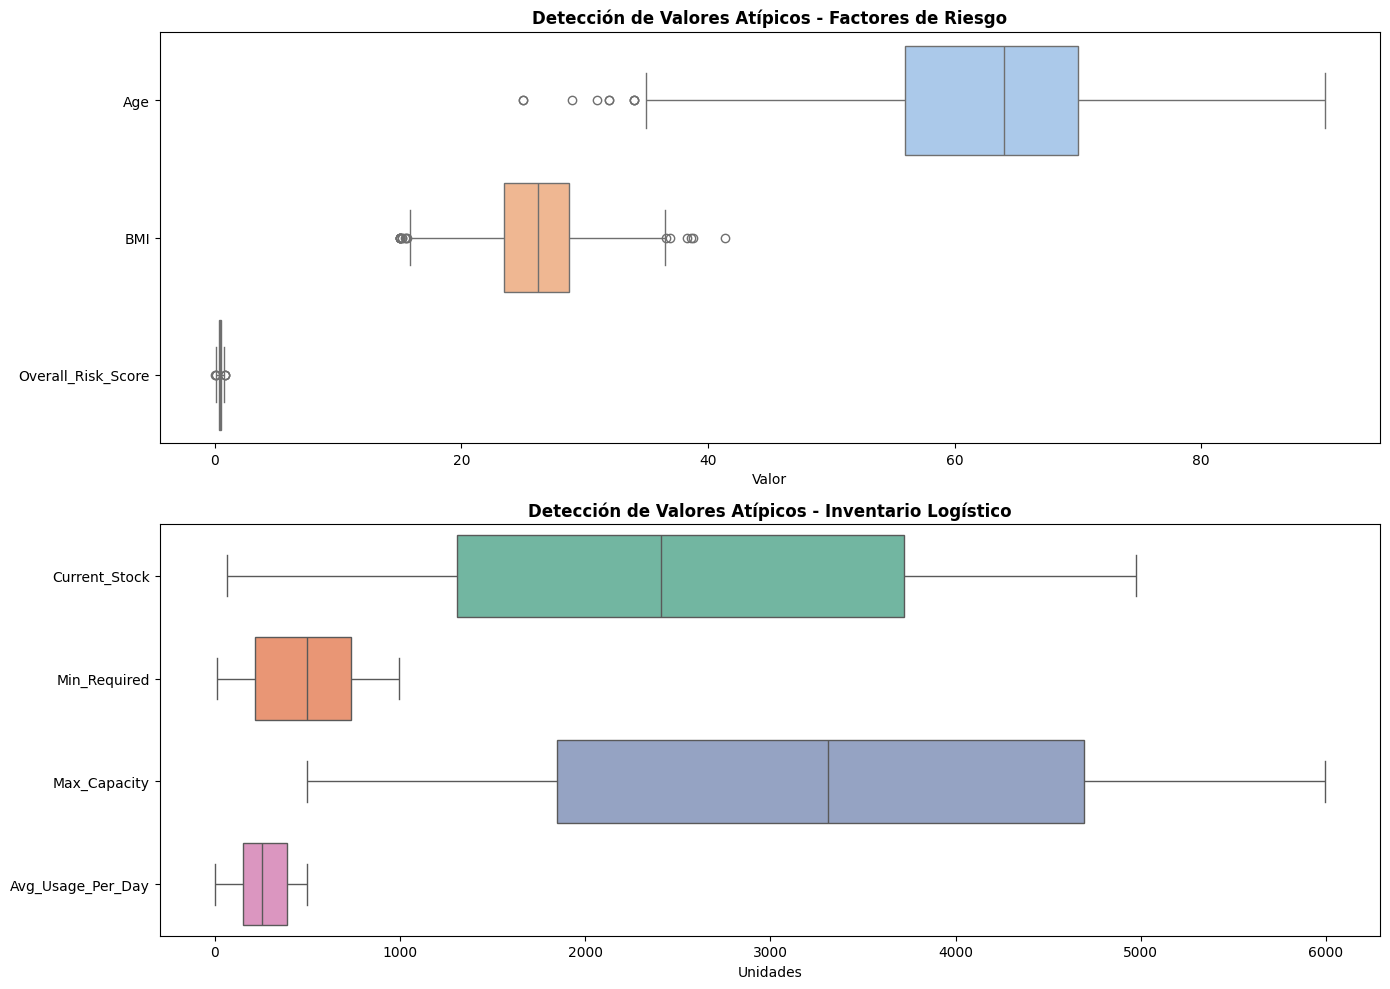

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

#Outliers en el Dataset Clínico
sns.boxplot(data=df_cancer[['Age', 'BMI', 'Overall_Risk_Score']], 
            orient='h', palette='pastel', ax=axes[0])
axes[0].set_title('Detección de Valores Atípicos - Factores de Riesgo', fontweight='bold')
axes[0].set_xlabel('Valor')

#Outliers en el Dataset Logístico
sns.boxplot(data=df_inventory[['Current_Stock', 'Min_Required', 'Max_Capacity', 'Avg_Usage_Per_Day']], 
            orient='h', palette='Set2', ax=axes[1])
axes[1].set_title('Detección de Valores Atípicos - Inventario Logístico', fontweight='bold')
axes[1].set_xlabel('Unidades')

plt.tight_layout()
plt.show()

# **EDA RIESGO DE SALUD**

### Distribuciones Iniciales de Factores de Riesgo
Análisis de la distribución de las variables numéricas más relevantes en el dataset de salud.

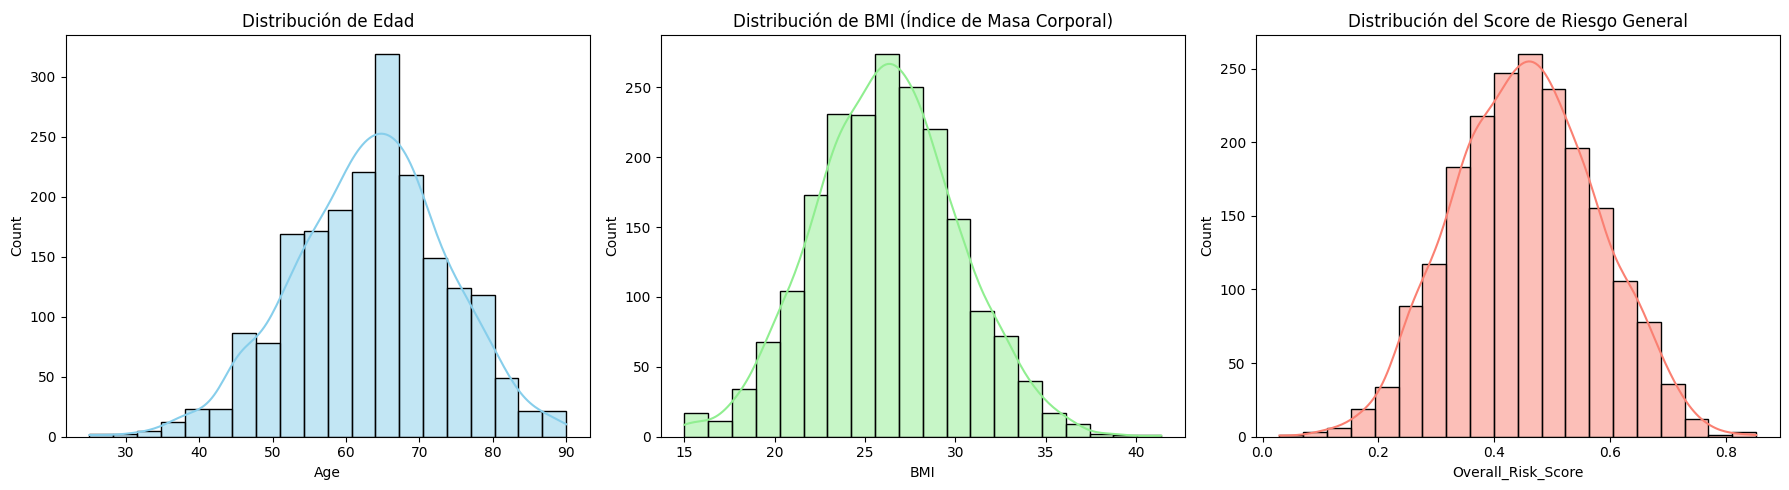

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df_cancer['Age'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Edad')
sns.histplot(df_cancer['BMI'], bins=20, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Distribución de BMI (Índice de Masa Corporal)')
sns.histplot(df_cancer['Overall_Risk_Score'], bins=20, kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Distribución del Score de Riesgo General')
plt.tight_layout()
plt.show()

C:\Users\Alejandro\AppData\Local\Temp\ipykernel_3960\445281230.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cancer, x='Risk_Level', palette='Reds_r', order=['High', 'Medium', 'Low'])


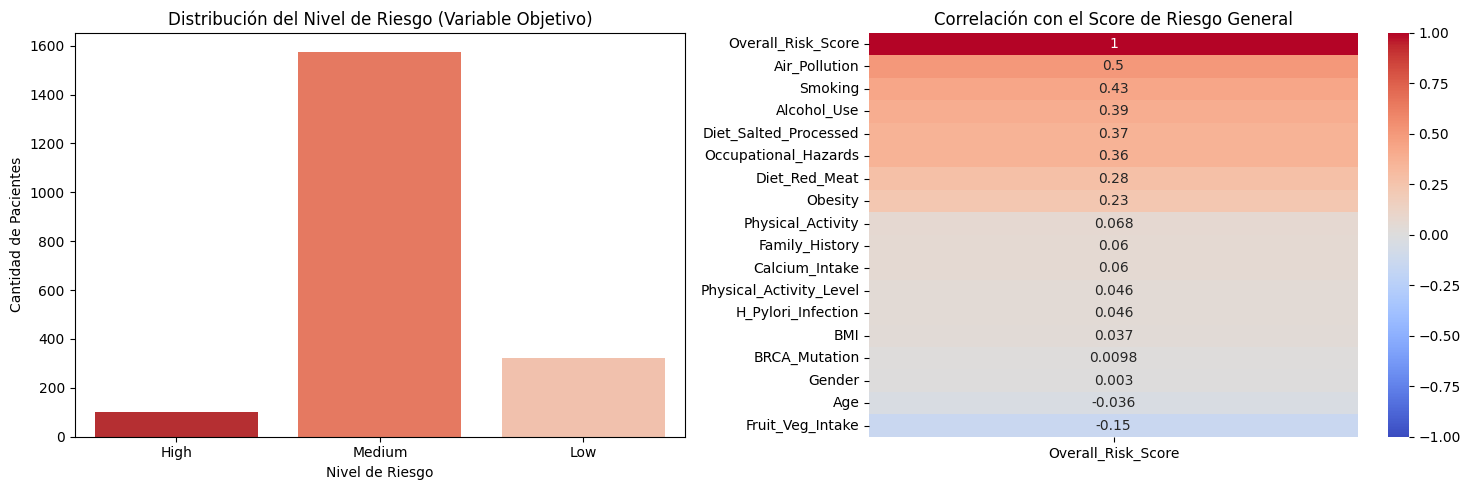

In [16]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df_cancer, x='Risk_Level', palette='Reds_r', order=['High', 'Medium', 'Low'])
plt.title('Distribución del Nivel de Riesgo (Variable Objetivo)')
plt.xlabel('Nivel de Riesgo')
plt.ylabel('Cantidad de Pacientes')

plt.subplot(1, 2, 2)
cols_num_cancer = df_cancer.select_dtypes(include=['float64', 'int64']).columns
corr_cancer = df_cancer[cols_num_cancer].corr()
sns.heatmap(corr_cancer[['Overall_Risk_Score']].sort_values(by='Overall_Risk_Score', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación con el Score de Riesgo General')

plt.tight_layout()
plt.show()

**1. Distribución del Nivel de Riesgo de Cáncer**

La variable objetivo presenta una distribución desbalanceada, con una clara predominancia de pacientes clasificados en el nivel de riesgo medio. Específicamente, aproximadamente el 80% de la población estudiada se encuentra en la categoría de riesgo medio (alrededor de 1,550 pacientes), mientras que solo el 5-7% se clasifica como riesgo alto y aproximadamente el 15% como riesgo bajo. Este desbalance es importante para considerar al entrenar modelos predictivos, ya que podría requerir técnicas de rebalanceo de clases para evitar que el modelo sea sesgado hacia la clase mayoritaria.

**2. Factores Correlacionados con el Riesgo General de Cáncer**

Los análisis de correlación revelan que los factores ambientales y de estilo de vida tienen influencias variables en el riesgo general de cáncer. La contaminación del aire destaca como el factor más fuertemente correlacionado (0.5), seguido por fumar (0.43) y el consumo de alcohol (0.39). Los factores dietéticos como el consumo de alimentos salados procesados (0.37) y carne roja (0.28) también muestran correlaciones moderadas. Sin embargo, variables como la edad (correlación ligeramente negativa de -0.036), el género (casi nula de 0.003) y algunas características fisiológicas como la infección por H. pylori y el BMI presentan correlaciones muy débiles. Destaca particularmente que el consumo de frutas y verduras muestra una débil correlación negativa (-0.15), sugiriendo un efecto protector. Esta información es crucial para la selección de características en futuros modelos predictivos.

### Análisis Bivariado: Nivel de Riesgo vs Tipo de Cáncer y Edad
Exploración de cómo se relaciona el nivel de prioridad o riesgo con el tipo de cáncer y la edad del paciente.


C:\Users\Alejandro\AppData\Local\Temp\ipykernel_3960\1389916114.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cancer, x='Risk_Level', y='Age', ax=axes[1], palette='Blues')


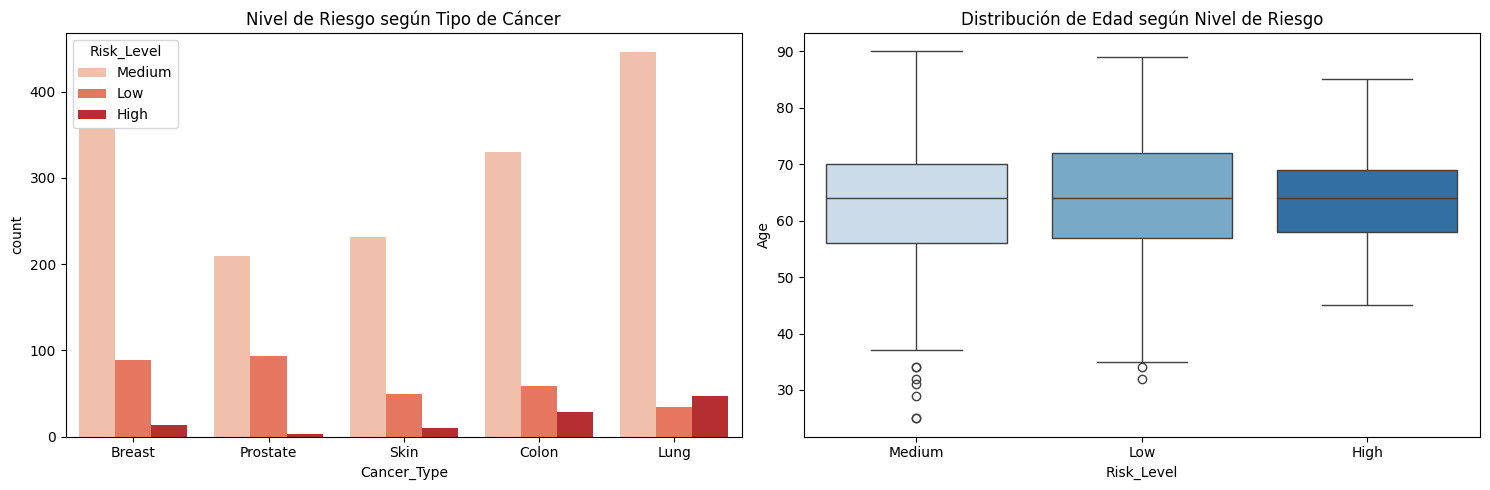

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=df_cancer, x='Cancer_Type', hue='Risk_Level', ax=axes[0], palette='Reds')
axes[0].set_title('Nivel de Riesgo según Tipo de Cáncer')

sns.boxplot(data=df_cancer, x='Risk_Level', y='Age', ax=axes[1], palette='Blues')
axes[1].set_title('Distribución de Edad según Nivel de Riesgo')

plt.tight_layout()
plt.show()


**Conclusiones del Análisis Bivariado:**

* **El Cáncer de Pulmón concentra la mayor criticidad:** Casi la mitad de los pacientes clasificados con Riesgo Alto padecen cáncer de pulmón. El modelo deberá dar especial peso a este diagnóstico para prever recursos críticos.
* **La Edad no es un predictor fuerte del nivel de riesgo:** La edad media (63.7 años) y la mediana (64 años) son virtualmente idénticas en pacientes de todos los niveles de riesgo. Otros factores clínicos o de estilo de vida traccionan el riesgo, no la edad.

# **EDA FRENTE LOGÍSTICO**

### Distribuciones Iniciales del Inventario
Análisis de la distribución del inventario y el uso promedio para evaluar la demanda.

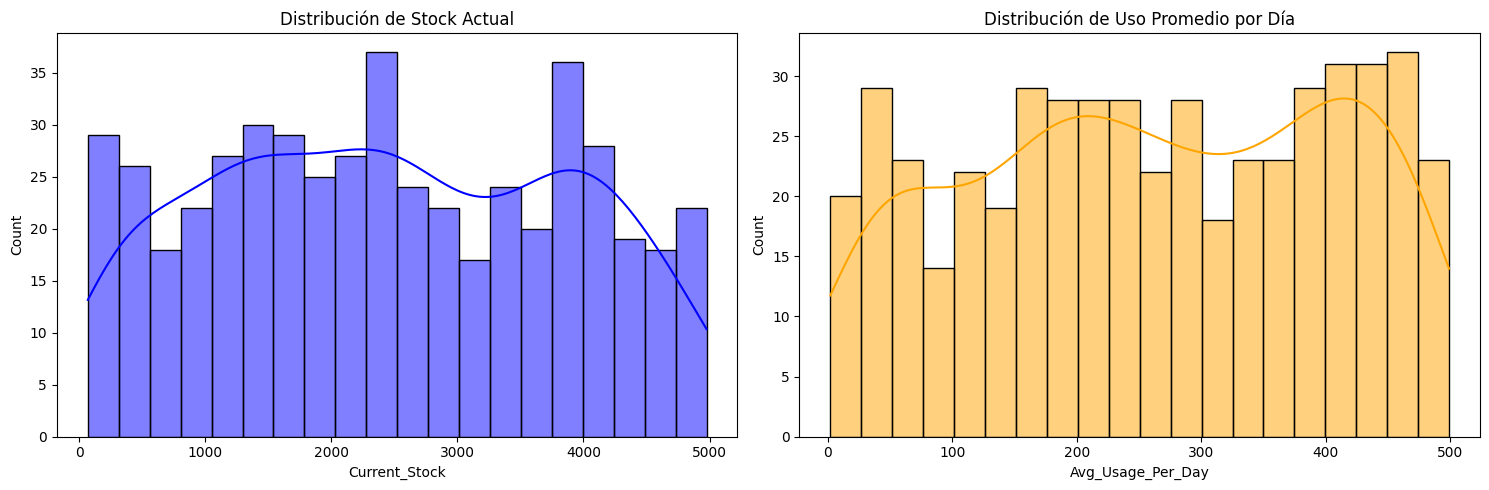

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df_inventory['Current_Stock'], bins=20, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribución de Stock Actual')
sns.histplot(df_inventory['Avg_Usage_Per_Day'], bins=20, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribución de Uso Promedio por Día')
plt.tight_layout()
plt.show()

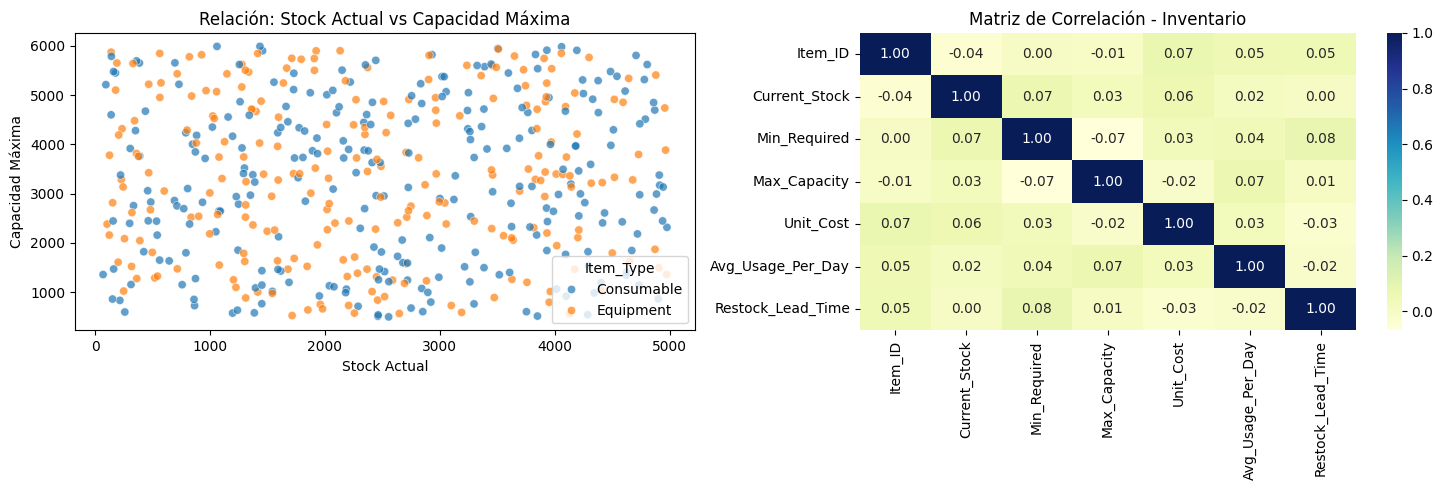

In [18]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df_inventory, x='Current_Stock', y='Max_Capacity', hue='Item_Type', alpha=0.7)
plt.title('Relación: Stock Actual vs Capacidad Máxima')
plt.xlabel('Stock Actual')
plt.ylabel('Capacidad Máxima')

plt.subplot(1, 2, 2)
cols_num_inv = df_inventory.select_dtypes(include=['float64', 'int64']).columns
corr_inv = df_inventory[cols_num_inv].corr()
sns.heatmap(corr_inv, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Matriz de Correlación - Inventario')

plt.tight_layout()
plt.show()

**3. Relación entre Stock Actual y Capacidad Máxima del Inventario**

El análisis del inventario muestra una relación dispersa entre el stock actual mantenido y la capacidad máxima disponible, sin un patrón lineal definido. Los datos se distribuyen en dos categorías según el tipo de artículo: consumibles (representados en azul) y equipos (en naranja), ambos mostrando una variabilidad similar. Mientras algunos artículos operan cerca de su capacidad máxima, otros mantienen niveles de stock significativamente más bajos. Esta dispersión sugiere que la gestión del inventario no sigue una regla proporcional simple y podría estar influenciada por factores específicos de cada artículo, como la demanda variable o las políticas de reorden diferenciadas.

**4. Correlaciones entre Variables del Inventario**

El análisis de correlación del inventario revela que las variables de este dataset presentan correlaciones muy débiles entre sí (valores cercanos a cero). Esto indica que cada variable del inventario (stock actual, costo unitario, uso diario promedio, tiempo de reorden, etc.) varía de forma relativamente independiente. Esta baja correlación sugiere que no existe multicolinealidad entre las variables, lo que es favorable para la modelización. Sin embargo, también implica que la variabilidad en una variable no puede ser explicada por cambios en otras, lo que podría significar que factores externos no capturados en el dataset ejercen una influencia importante en la gestión del inventario.

### Análisis de Reabastecimiento y Stock por Tipo de Artículo
Evaluación del tiempo de reabastecimiento y la relación de stock crítico según la categoría del artículo.


C:\Users\Alejandro\AppData\Local\Temp\ipykernel_3960\2520454943.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_inventory, x='Item_Type', y='Restock_Lead_Time', ax=axes[0], palette='Set2')


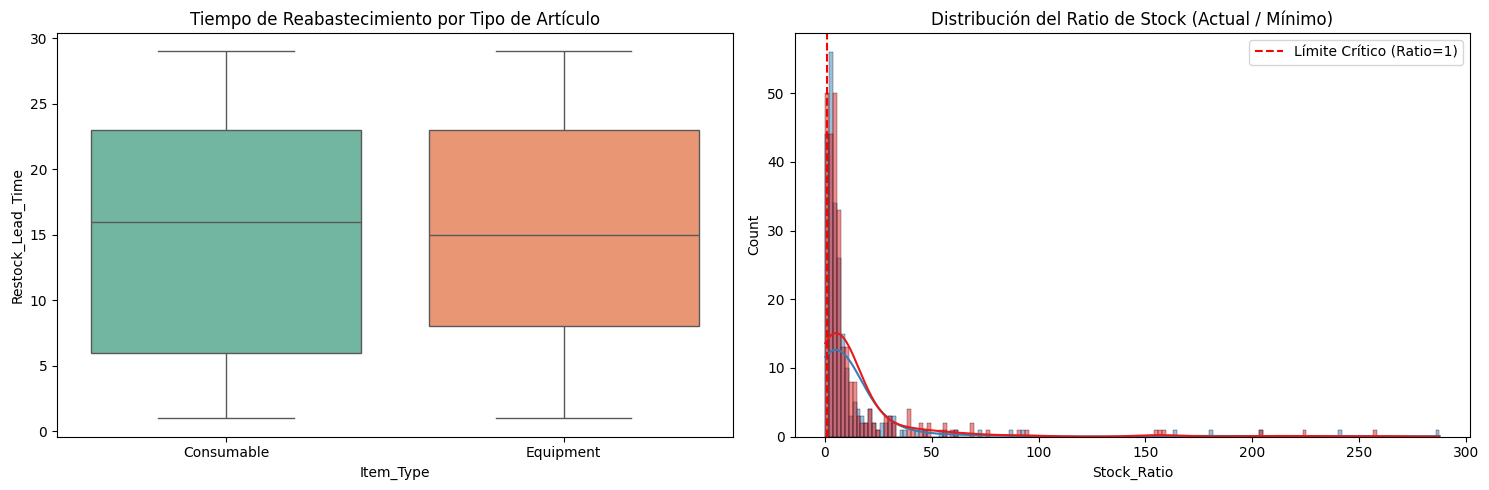

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df_inventory, x='Item_Type', y='Restock_Lead_Time', ax=axes[0], palette='Set2')
axes[0].set_title('Tiempo de Reabastecimiento por Tipo de Artículo')

# Crear variable temporal de estado de stock (Stock actual / Mínimo requerido)
df_inventory['Stock_Ratio'] = df_inventory['Current_Stock'] / df_inventory['Min_Required']
sns.histplot(data=df_inventory, x='Stock_Ratio', hue='Item_Type', kde=True, ax=axes[1], palette='Set1')
axes[1].set_title('Distribución del Ratio de Stock (Actual / Mínimo)')
axes[1].axvline(1, color='red', linestyle='--', label='Límite Crítico (Ratio=1)')
axes[1].legend()

plt.tight_layout()
plt.show()


**Conclusiones del Análisis Logístico:**

* **Tiempos de Reabastecimiento uniformes:** Los proveedores tardan en promedio 15 días en despachar tanto Equipos como Consumibles. Las alertas de predicción deberán emitirse con al menos 2 a 3 semanas de anticipación para evitar desabastecimientos.
* **Alerta de Stock Crítico:** Existen 43 artículos (casi el 9% del inventario) con un Ratio de Stock <= 1 (stock menor o igual al mínimo). De ellos, la mayoría (27) son consumibles. El modelo predictivo debe enfocarse fuertemente en esta categoría, pues representan suministros vitales (medicamentos, alimentos) y están al borde del desabastecimiento.